<a href="https://colab.research.google.com/github/Suryasenthi/surya/blob/main/Task_1_Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
df = pd.read_csv("Weather_Data.csv")



In [22]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"])
df["year"] = df["Date/Time"].dt.year
df["month"] = df["Date/Time"].dt.month
df["day"] = df["Date/Time"].dt.day
df["hour"] = df["Date/Time"].dt.hour

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Weather_encoded"] = le.fit_transform(df["Weather"])


In [23]:
X = df[["Dew Point Temp_C", "Rel Hum_%", "Wind Speed_km/h",
        "Visibility_km", "Press_kPa", "hour", "month", "day", "Weather_encoded"]]

y = df["Temp_C"]


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [26]:
y_pred = model.predict(X_test)


In [29]:


output_df = pd.DataFrame({
    "Date/Time": df.loc[X_test.index, "Date/Time"],
    "Actual_Temp_C": y_test.values,
    "Predicted_Temp_C": y_pred
})

output_df.to_csv("Weather_Prediction_Output.csv", index=False)

print("CSV saved as Weather_Prediction_Output.csv")


CSV saved as Weather_Prediction_Output.csv


In [30]:
from google.colab import files
files.download("Weather_Prediction_Output.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

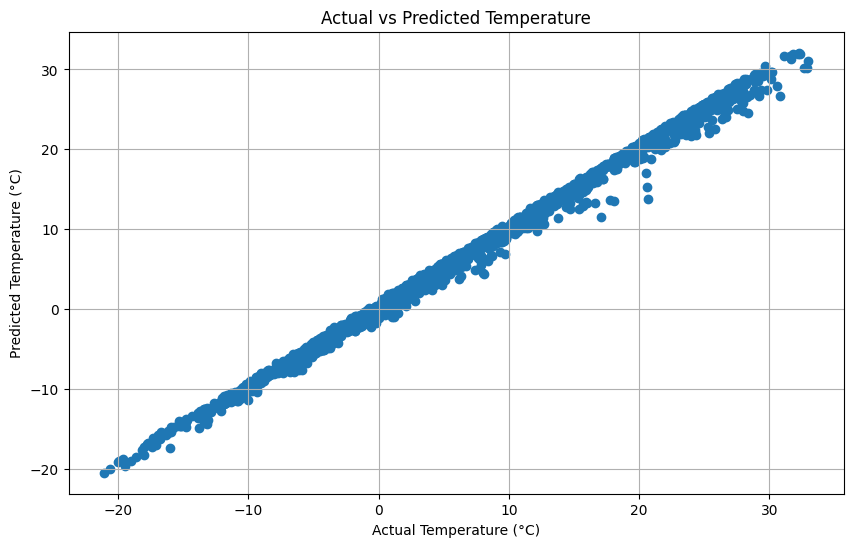

In [31]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature")
plt.grid(True)
plt.show()
